<a href="https://colab.research.google.com/github/krishna-gunda/Deep_Learning_concepts/blob/main/binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip -FF "/content/archive (1).zip" -d /content/

Archive:  /content/archive (1).zip
  inflating: /content/animals/cat/00067-200124377.png  
  inflating: /content/animals/cat/00068-200124378.png  
  inflating: /content/animals/cat/00069-200124379.png  
  inflating: /content/animals/cat/00070-200124380.png  
  inflating: /content/animals/cat/00071-200124381.png  
  inflating: /content/animals/cat/00072-200124382.png  
  inflating: /content/animals/cat/00073-200124383.png  
  inflating: /content/animals/cat/00074-200124384.png  
  inflating: /content/animals/cat/00075-200124385.png  
  inflating: /content/animals/cat/00076-200124386.png  
  inflating: /content/animals/cat/00077-200124387.png  
  inflating: /content/animals/cat/00078-200124388.png  
  inflating: /content/animals/cat/00079-200124389.png  
  inflating: /content/animals/cat/00080-200124390.png  
  inflating: /content/animals/cat/00081-200124391.png  
  inflating: /content/animals/cat/00082-200124392.png  
  inflating: /content/animals/cat/00083-200124393.png  
  inflating: 

In [2]:
!unzip -FF "/content/test.zip" -d /content/

Archive:  /content/test.zip
   creating: /content/cats/
  inflating: /content/cats/cat_190.jpg  
  inflating: /content/cats/cat_147.jpg  
  inflating: /content/cats/cat_542.jpg  
  inflating: /content/cats/cat_595.jpg  
  inflating: /content/cats/cat_422.jpg  
  inflating: /content/cats/cat_583.jpg  
  inflating: /content/cats/cat_384.jpg  
  inflating: /content/cats/cat_586.jpg  
  inflating: /content/cats/cat_545.jpg  
  inflating: /content/cats/cat_223.jpg  
  inflating: /content/cats/cat_551.jpg  
  inflating: /content/cats/cat_587.jpg  
  inflating: /content/cats/cat_140.jpg  
  inflating: /content/cats/cat_342.jpg  
  inflating: /content/cats/cat_430.jpg  
  inflating: /content/cats/cat_418.jpg  
  inflating: /content/cats/cat_395.jpg  
  inflating: /content/cats/cat_156.jpg  
  inflating: /content/cats/cat_585.jpg  
  inflating: /content/cats/cat_234.jpg  
  inflating: /content/cats/cat_355.jpg  
  inflating: /content/cats/cat_433.jpg  
  inflating: /content/cats/cat_341.jpg  
 

In [3]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
train_path="/content/train"
val_path='/content/val'

In ImageDataGenerator, we use different parameters to preprocess and augment images so the model can learn better and avoid overfitting. The rescale=1/255 parameter is used to normalize pixel values from 0–255 to 0–1, which helps in faster and more stable training. The rotation_range=20 randomly rotates images within a small angle so the model can recognize objects even when they are slightly tilted. The shear_range=0.2 slightly distorts or slants the image, helping the model handle variations in shape and perspective. The horizontal_flip=True flips images left to right, allowing the model to learn that objects can appear in different directions. These transformations are mainly applied to training data to create multiple variations of the same image, making the model more robust and improving its ability to generalize to new, unseen data.

In [6]:
train_data_preprocessing=ImageDataGenerator(rescale=1/255, # here we rescale image picxel value *(1/255)
                                            rotation_range=20,
                                            shear_range=0.2, #Instead of rotating, the image is pushed sideways
                                            horizontal_flip=True)

In [7]:
val_data_preprocessing=ImageDataGenerator(rescale=1/255)

In [8]:
final_train=train_data_preprocessing.flow_from_directory(train_path,target_size=(255,255),
                                                         class_mode='binary',classes=['cat','dog'],
                                                         batch_size=20)

Found 933 images belonging to 2 classes.


In [9]:
final_train.class_indices # we can check which class belongs to 0 or 1

{'cat': 0, 'dog': 1}

In [10]:
final_val=train_data_preprocessing.flow_from_directory(val_path,target_size=(255,255),
                                                         class_mode='binary',classes=['cat','dog'],
                                                         batch_size=20)

Found 140 images belonging to 2 classes.


In [11]:
final_val.class_indices

{'cat': 0, 'dog': 1}

**now we have to built the architecture**

In [12]:
# architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Activation,MaxPool2D,Flatten
from tensorflow.keras.activations import relu,sigmoid # we use relu for hidden layers and sigmoid for outputlayer

In [15]:
model=Sequential()
# 1st hidden layer
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='valid',
                 kernel_initializer='he_uniform',activation=relu))
model.add(MaxPool2D(pool_size=(2,2)))

# second hidden layer
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='valid',
                 kernel_initializer='he_uniform',activation=relu))
model.add(MaxPool2D(pool_size=(2,2)))
# third layer
model.add(Conv2D(filters=16,kernel_size=(3,3),padding='valid',
                 kernel_initializer='he_uniform',activation=relu))
model.add(MaxPool2D(pool_size=(2,2)))
# 4th layer
model.add(Conv2D(filters=4,kernel_size=(3,3),padding='valid',
                 kernel_initializer='he_uniform',activation=relu))
model.add(MaxPool2D(pool_size=(2,2)))

#flatten layer
model.add(Flatten())


#give to ann
model.add(Dense(units=64,kernel_initializer='he_uniform',activation=relu))
model.add(Dense(units=32,kernel_initializer='he_uniform',activation=relu))
model.add(Dense(units=16,kernel_initializer='he_uniform',activation=relu))
model.add(Dense(units=1,kernel_initializer="glorot_uniform",activation=sigmoid))




In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**The compile function defines the optimizer for weight updates, the loss function to measure error, and metrics to evaluate model performance during training.**

In [18]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['Accuracy'])

In [19]:
model.fit(final_train,validation_data=final_val,epochs=10)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 664ms/step - Accuracy: 0.6024 - loss: 0.6733 - val_Accuracy: 0.4786 - val_loss: 0.8738
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 564ms/step - Accuracy: 0.7546 - loss: 0.5240 - val_Accuracy: 0.4571 - val_loss: 1.1977
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 570ms/step - Accuracy: 0.8403 - loss: 0.3648 - val_Accuracy: 0.5929 - val_loss: 0.8212
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 563ms/step - Accuracy: 0.9057 - loss: 0.2318 - val_Accuracy: 0.6071 - val_loss: 1.2724
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 556ms/step - Accuracy: 0.9486 - loss: 0.1469 - val_Accuracy: 0.6143 - val_loss: 1.0463
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 566ms/step - Accuracy: 0.9357 - loss: 0.1656 - val_Accuracy: 0.6000 - val_loss: 1.1117
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 559ms/step - Accuracy: 0.9689 - loss: 0.0936 - val_Accuracy: 0.6286 - val_loss: 1.1323
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 554ms/step - Accuracy: 0.9668 - loss: 0.0813 - val_Accu

In [21]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt

In [43]:
from google.colab.patches import cv2_imshow

In [46]:
import cv2
import numpy as np

def predict_image(path):

    img = cv2.imread(path)
    cv2_imshow(img)


    if img is None:
        print("Image not found")
        return

    img = cv2.resize(img, (255, 255))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    result = model.predict(img)

    if result[0][0] <= 0.5:
        print("Cat")
    else:
        print("Dog")

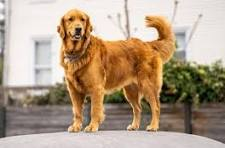

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Dog


In [47]:
predict_image('/content/download (2).jpeg')

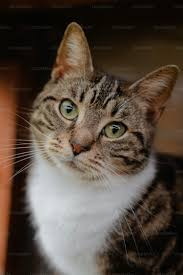

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Cat


In [48]:
predict_image('/content/images.jpeg')

In [34]:
final_train.class_indices

{'cat': 0, 'dog': 1}

In [37]:
image=cv2.imread('/content/images.jpeg')

In [31]:
print(image.shape)

(275, 183, 3)
